In [12]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/flights_data_cleaned.csv")


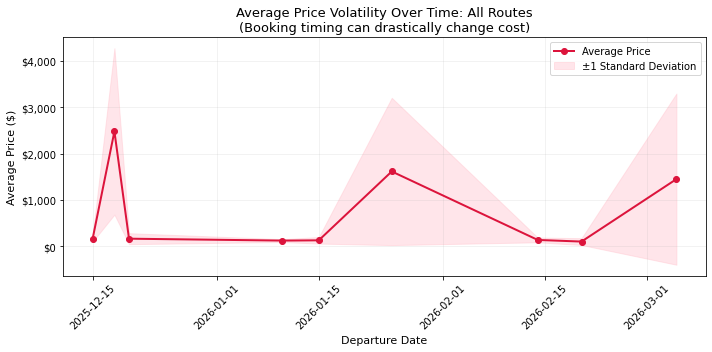

In [14]:
price_stats['departure_date'] = pd.to_datetime(price_stats['departure_date'])

# Sort by date
price_stats = price_stats.sort_values("departure_date")

# Set up figure
plt.figure(figsize=(10, 5))

# Line and shaded region
plt.plot(price_stats["departure_date"], price_stats["mean"], color='crimson', marker='o', linewidth=2, label='Average Price')
plt.fill_between(price_stats["departure_date"],
                 price_stats["mean"] - price_stats["std"],
                 price_stats["mean"] + price_stats["std"],
                 color='pink', alpha=0.4, label='±1 Standard Deviation')

# Format y-axis as currency
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('${x:,.0f}'))

# Titles and labels
plt.title("Average Price Volatility Over Time: All Routes\n(Booking timing can drastically change cost)", fontsize=13)
plt.xlabel("Departure Date", fontsize=11)
plt.ylabel("Average Price ($)", fontsize=11)
plt.xticks(rotation=45)

# Layout, legend, grid, and save
plt.tight_layout()
plt.grid(alpha=0.2)
plt.legend()
plt.savefig("price_volatility.png", dpi=300)
plt.show()


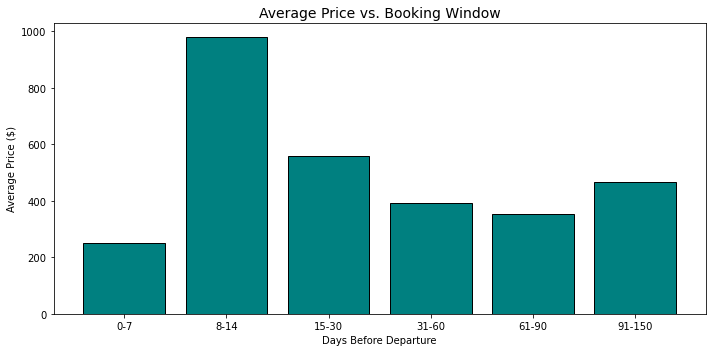

In [5]:
# Create bins for days until departure
df['booking_bin'] = pd.cut(df['days_until_departure'], bins=[0, 7, 14, 30, 60, 90, 150, 365],
                           labels=['0-7', '8-14', '15-30', '31-60', '61-90', '91-150', '150+'])

booking_trend = df.groupby('booking_bin')['price'].mean().reset_index()

# Plot
plt.figure(figsize=(10, 5))
plt.bar(booking_trend['booking_bin'], booking_trend['price'], color='teal', edgecolor='black')
plt.title("Average Price vs. Booking Window", fontsize=14)
plt.xlabel("Days Before Departure")
plt.ylabel("Average Price ($)")
plt.tight_layout()
plt.savefig("booking_window.png", dpi=300)
plt.show()


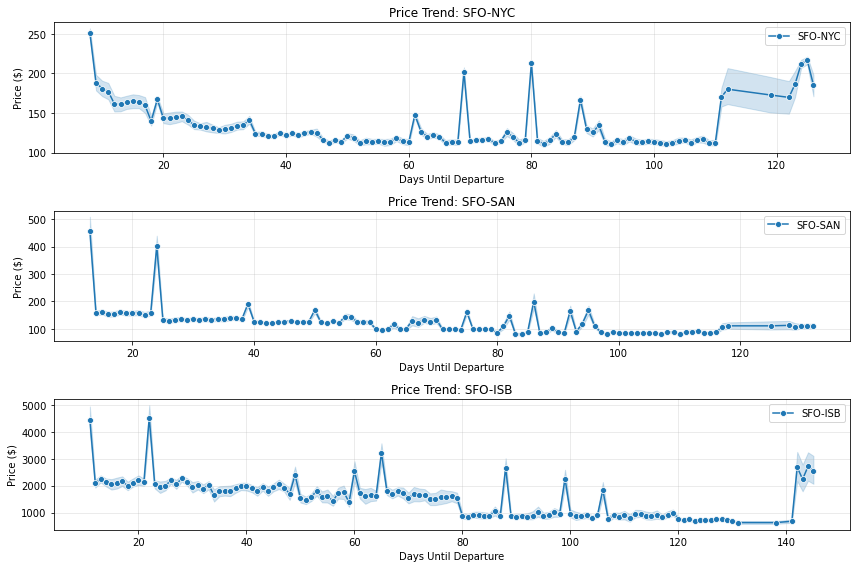

In [29]:
# Convert dates if necessary
df['scraped_date'] = pd.to_datetime(df['scraped_date'])
df['departure_date'] = pd.to_datetime(df['departure_date'])

# Calculate 'days_until_departure'
df['days_until_departure'] = (df['departure_date'] - df['scraped_date']).dt.days

# Plot: Booking Window vs. Price for each Route
plt.figure(figsize=(12, 8))
routes = df['route'].unique()

for i, route in enumerate(routes, 1):
    plt.subplot(len(routes), 1, i)
    sns.lineplot(data=df[df['route'] == route], 
                 x='days_until_departure', 
                 y='price', 
                 marker='o', 
                 label=route)
    plt.title(f"Price Trend: {route}")
    plt.xlabel("Days Until Departure")
    plt.ylabel("Price ($)")
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("booking_window_per_route.png", dpi=300)
plt.show()


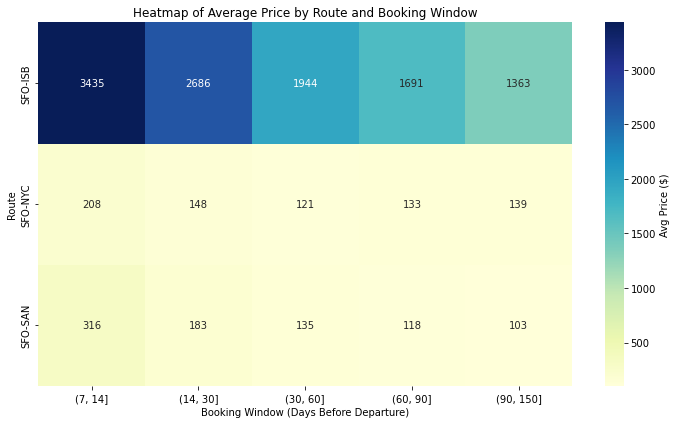

In [30]:
pivot_table = df.pivot_table(index='route', 
                             columns=pd.cut(df['days_until_departure'], 
                                            bins=[0, 7, 14, 30, 60, 90, 150, 365]), 
                             values='price', 
                             aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, cmap="YlGnBu", annot=True, fmt=".0f", cbar_kws={'label': 'Avg Price ($)'})
plt.title("Heatmap of Average Price by Route and Booking Window")
plt.xlabel("Booking Window (Days Before Departure)")
plt.ylabel("Route")
plt.tight_layout()
plt.savefig("price_heatmap.png", dpi=300)
plt.show()


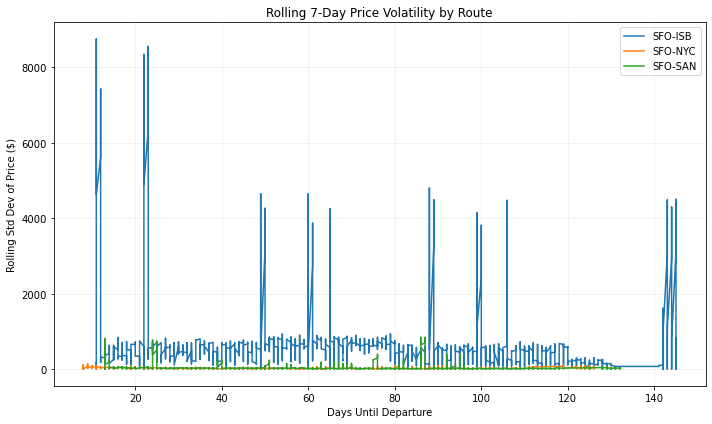

In [32]:
# Ensure your dataframe 'df' has 'route', 'days_until_departure', and 'price'
df_sorted = df.sort_values(['route', 'days_until_departure'])

# Compute 7-day rolling standard deviation for each route
rolling_std = (
    df_sorted.groupby('route')[['days_until_departure', 'price']]
    .apply(lambda g: g.set_index('days_until_departure').rolling(window=7).std().reset_index())
    .reset_index(drop=True)
)

# Merge with route info for plotting
rolling_std['route'] = df_sorted['route'].values

# Plotting
plt.figure(figsize=(10, 6))
for route in rolling_std['route'].unique():
    subset = rolling_std[rolling_std['route'] == route]
    plt.plot(subset['days_until_departure'], subset['price'], label=route)

plt.title('Rolling 7-Day Price Volatility by Route')
plt.xlabel('Days Until Departure')
plt.ylabel('Rolling Std Dev of Price ($)')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig("rolling_price_volatility.png", dpi=300)
plt.show()
